In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 16.9 MB/s eta 0:00:00


69.80620155038763
69.80620155038763


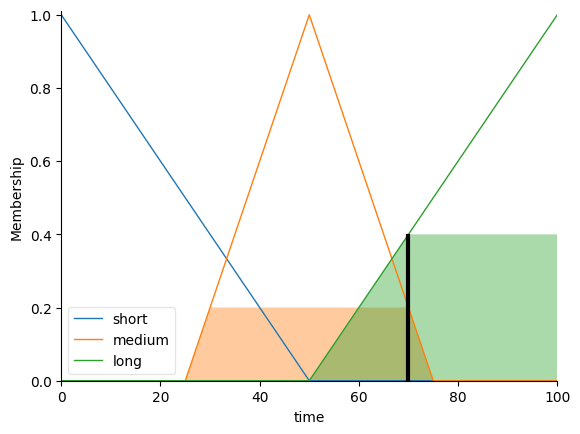

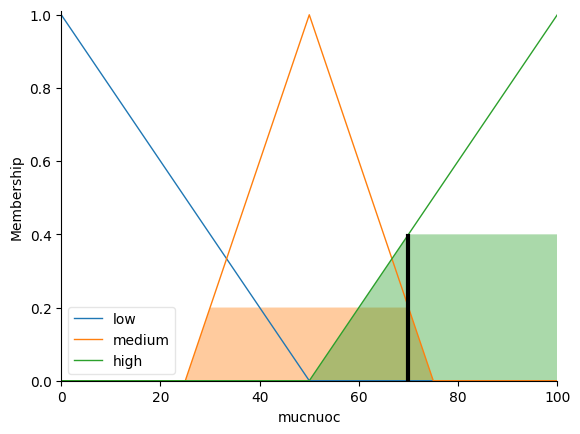

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

load = ctrl.Antecedent(np.arange(0, 101, 1), 'load')
dirt_level = ctrl.Antecedent(np.arange(0, 101, 1), 'dirt_level')
fabric_type = ctrl.Antecedent(np.arange(0, 101, 1), 'fabric_type')

time = ctrl.Consequent(np.arange(0, 101, 1), 'time')
mucnuoc = ctrl.Consequent(np.arange(0, 101, 1), 'mucnuoc')

load['low'] = fuzz.trimf(load.universe, [0, 0, 50])
load['medium'] = fuzz.trimf(load.universe, [25, 50, 75])
load['high'] = fuzz.trimf(load.universe, [50, 100, 100])

dirt_level['low'] = fuzz.trimf(dirt_level.universe, [0, 0, 50])
dirt_level['medium'] = fuzz.trimf(dirt_level.universe, [25, 50, 75])
dirt_level['high'] = fuzz.trimf(dirt_level.universe, [50, 100, 100])

fabric_type['thin'] = fuzz.trimf(fabric_type.universe, [0, 0, 50])
fabric_type['normal'] = fuzz.trimf(fabric_type.universe, [25, 50, 75])
fabric_type['thick'] = fuzz.trimf(fabric_type.universe, [50, 100, 100])

time['short'] = fuzz.trimf(time.universe, [0, 0, 50])
time['medium'] = fuzz.trimf(time.universe, [25, 50, 75])
time['long'] = fuzz.trimf(time.universe, [50, 100, 100])

mucnuoc['low'] = fuzz.trimf(mucnuoc.universe, [0, 0, 50])
mucnuoc['medium'] = fuzz.trimf(mucnuoc.universe, [25, 50, 75])
mucnuoc['high'] = fuzz.trimf(mucnuoc.universe, [50, 100, 100])

rule1 = ctrl.Rule(load['low'] & dirt_level['low'] & fabric_type['thin'], (time['short'], mucnuoc['low']))
rule2 = ctrl.Rule(load['medium'] & dirt_level['medium'] & fabric_type['normal'], (time['medium'], mucnuoc['medium']))
rule3 = ctrl.Rule(load['high'] | dirt_level['high'] | fabric_type['thick'], (time['long'], mucnuoc['high']))

washing_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
washing = ctrl.ControlSystemSimulation(washing_ctrl)

washing.input['load'] = 60
washing.input['dirt_level'] = 70
washing.input['fabric_type'] = 50

washing.compute()

print(washing.output['time'])
print(washing.output['mucnuoc'])

time.view(sim=washing)
mucnuoc.view(sim=washing)

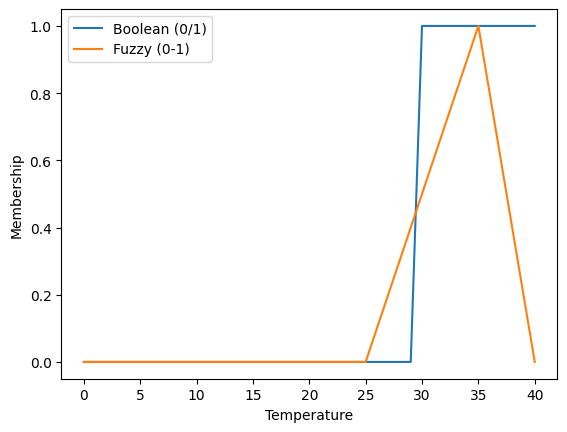

Boolean: 0
Fuzzy: 0.3


In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

x = np.arange(0, 41, 1)

boolean_hot = [1 if i >= 30 else 0 for i in x]

fuzzy_hot = fuzz.trimf(x, [25, 35, 40])

plt.plot(x, boolean_hot, label='Boolean (0/1)')
plt.plot(x, fuzzy_hot, label='Fuzzy (0-1)')
plt.xlabel('Temperature')
plt.ylabel('Membership')
plt.legend()
plt.show()

temp = 28

boolean_result = 1 if temp >= 30 else 0
fuzzy_result = fuzz.interp_membership(x, fuzzy_hot, temp)

print("Boolean:", boolean_result)
print("Fuzzy:", fuzzy_result)

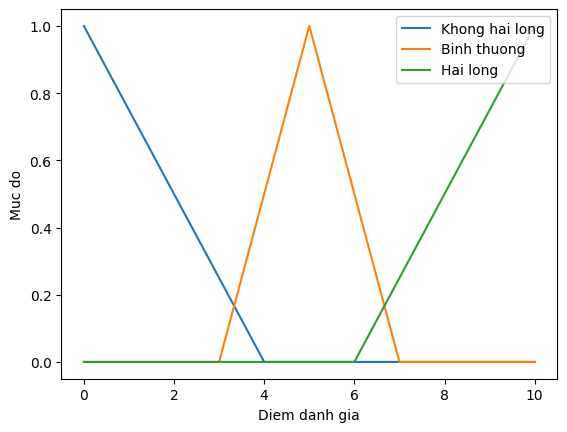

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

x = np.arange(0, 11, 1)

unhappy = fuzz.trimf(x, [0, 0, 4])
normal = fuzz.trimf(x, [3, 5, 7])
happy = fuzz.trimf(x, [6, 10, 10])

plt.plot(x, unhappy, label='Khong hai long')
plt.plot(x, normal, label='Binh thuong')
plt.plot(x, happy, label='Hai long')

plt.xlabel('Diem danh gia')
plt.ylabel('Muc do')
plt.legend()
plt.show()

8.142857142857142


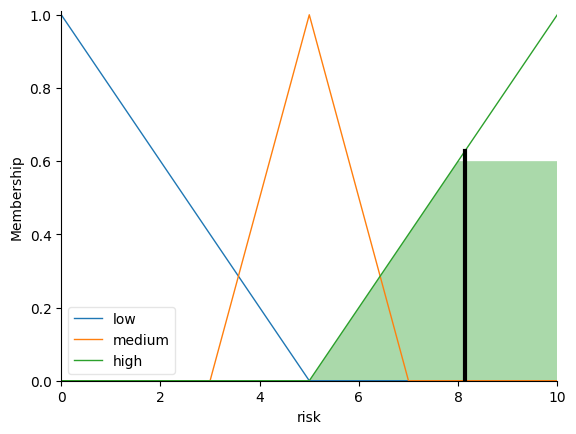

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

cost = ctrl.Antecedent(np.arange(0, 11, 1), 'cost')
time = ctrl.Antecedent(np.arange(0, 11, 1), 'time')
risk = ctrl.Consequent(np.arange(0, 11, 1), 'risk')

cost['low'] = fuzz.trimf(cost.universe, [0, 0, 5])
cost['medium'] = fuzz.trimf(cost.universe, [3, 5, 7])
cost['high'] = fuzz.trimf(cost.universe, [5, 10, 10])

time['short'] = fuzz.trimf(time.universe, [0, 0, 5])
time['medium'] = fuzz.trimf(time.universe, [3, 5, 7])
time['long'] = fuzz.trimf(time.universe, [5, 10, 10])

risk['low'] = fuzz.trimf(risk.universe, [0, 0, 5])
risk['medium'] = fuzz.trimf(risk.universe, [3, 5, 7])
risk['high'] = fuzz.trimf(risk.universe, [5, 10, 10])

rule1 = ctrl.Rule(cost['low'] & time['short'], risk['low'])
rule2 = ctrl.Rule(cost['medium'] & time['medium'], risk['medium'])
rule3 = ctrl.Rule(cost['high'] | time['long'], risk['high'])

system = ctrl.ControlSystem([rule1, rule2, rule3])
sim = ctrl.ControlSystemSimulation(system)

sim.input['cost'] = 7
sim.input['time'] = 8

sim.compute()

print(sim.output['risk'])

risk.view(sim=sim)

In [ ]:
import numpy as np
import skfuzzy as fuzz

x = np.linspace(0, 10, 100)

mf = fuzz.trimf(x, [2, 5, 8])

centroid = fuzz.defuzz(x, mf, 'centroid')
mom = fuzz.defuzz(x, mf, 'mom')
som = fuzz.defuzz(x, mf, 'som')
lom = fuzz.defuzz(x, mf, 'lom')

print("Centroid:", centroid)
print("MOM:", mom)
print("SOM:", som)
print("LOM:", lom)

Centroid: 5.000000000000003
MOM: 5.0
SOM: 4.94949494949495
LOM: 5.05050505050505


7.740740740740741


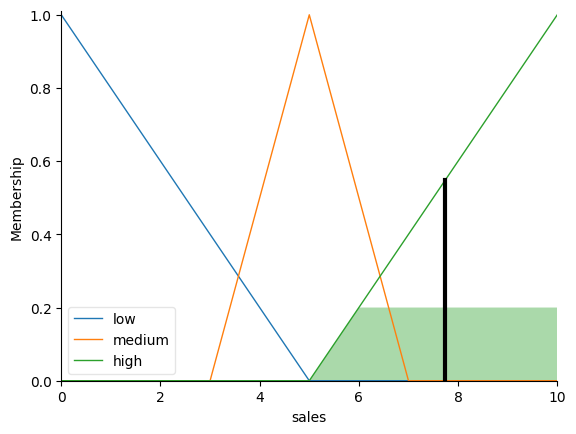

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

demand = ctrl.Antecedent(np.arange(0, 11, 1), 'demand')
price = ctrl.Antecedent(np.arange(0, 11, 1), 'price')
ads = ctrl.Antecedent(np.arange(0, 11, 1), 'ads')

sales = ctrl.Consequent(np.arange(0, 11, 1), 'sales')

demand['low'] = fuzz.trimf(demand.universe, [0, 0, 5])
demand['medium'] = fuzz.trimf(demand.universe, [3, 5, 7])
demand['high'] = fuzz.trimf(demand.universe, [5, 10, 10])

price['low'] = fuzz.trimf(price.universe, [0, 0, 5])
price['medium'] = fuzz.trimf(price.universe, [3, 5, 7])
price['high'] = fuzz.trimf(price.universe, [5, 10, 10])

ads['low'] = fuzz.trimf(ads.universe, [0, 0, 5])
ads['medium'] = fuzz.trimf(ads.universe, [3, 5, 7])
ads['high'] = fuzz.trimf(ads.universe, [5, 10, 10])

sales['low'] = fuzz.trimf(sales.universe, [0, 0, 5])
sales['medium'] = fuzz.trimf(sales.universe, [3, 5, 7])
sales['high'] = fuzz.trimf(sales.universe, [5, 10, 10])

rule1 = ctrl.Rule(demand['high'] & ads['high'] & price['low'], sales['high'])
rule2 = ctrl.Rule(demand['medium'] & ads['medium'], sales['medium'])
rule3 = ctrl.Rule(price['high'] | demand['low'], sales['low'])

system = ctrl.ControlSystem([rule1, rule2, rule3])
sim = ctrl.ControlSystemSimulation(system)

sim.input['demand'] = 8
sim.input['price'] = 4
sim.input['ads'] = 7

sim.compute()

print(sim.output['sales'])

sales.view(sim=sim)

7.740740740740741


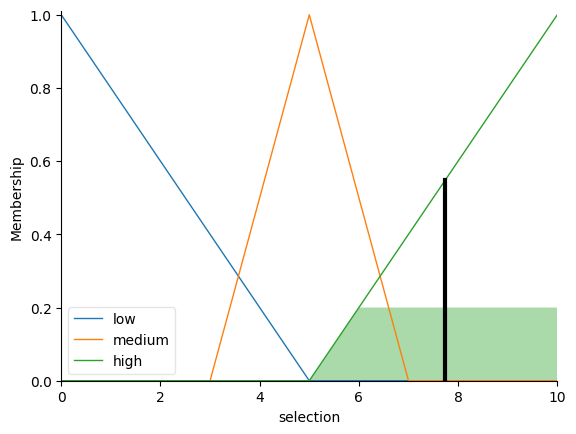

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

price = ctrl.Antecedent(np.arange(0, 11, 1), 'price')
quality = ctrl.Antecedent(np.arange(0, 11, 1), 'quality')
delivery = ctrl.Antecedent(np.arange(0, 11, 1), 'delivery')

selection = ctrl.Consequent(np.arange(0, 11, 1), 'selection')

price['low'] = fuzz.trimf(price.universe, [0, 0, 5])
price['medium'] = fuzz.trimf(price.universe, [3, 5, 7])
price['high'] = fuzz.trimf(price.universe, [5, 10, 10])

quality['low'] = fuzz.trimf(quality.universe, [0, 0, 5])
quality['medium'] = fuzz.trimf(quality.universe, [3, 5, 7])
quality['high'] = fuzz.trimf(quality.universe, [5, 10, 10])

delivery['fast'] = fuzz.trimf(delivery.universe, [0, 0, 5])
delivery['medium'] = fuzz.trimf(delivery.universe, [3, 5, 7])
delivery['slow'] = fuzz.trimf(delivery.universe, [5, 10, 10])

selection['low'] = fuzz.trimf(selection.universe, [0, 0, 5])
selection['medium'] = fuzz.trimf(selection.universe, [3, 5, 7])
selection['high'] = fuzz.trimf(selection.universe, [5, 10, 10])

rule1 = ctrl.Rule(price['low'] & quality['high'] & delivery['fast'], selection['high'])
rule2 = ctrl.Rule(price['medium'] & quality['medium'], selection['medium'])
rule3 = ctrl.Rule(price['high'] | delivery['slow'] | quality['low'], selection['low'])

system = ctrl.ControlSystem([rule1, rule2, rule3])
sim = ctrl.ControlSystemSimulation(system)

sim.input['price'] = 4
sim.input['quality'] = 8
sim.input['delivery'] = 3

sim.compute()

print(sim.output['selection'])

selection.view(sim=sim)

In [ ]:
import numpy as np
import skfuzzy as fuzz

data = np.array([
    [1, 2],
    [2, 3],
    [3, 4],
    [8, 9],
    [9, 10],
    [10, 11]
]).T

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data, c=2, m=2, error=0.005, maxiter=1000
)

print("Tam cum:\n", cntr)
print("Membership:\n", u)

Tam cum:
 [[ 1.99624878  2.99624878]
 [ 9.00378246 10.00378246]]
Membership:
 [[9.84743041e-01 9.99999713e-01 9.72808715e-01 2.71932069e-02
  2.91667575e-07 1.52561337e-02]
 [1.52569588e-02 2.86866441e-07 2.71912848e-02 9.72806793e-01
  9.99999708e-01 9.84743866e-01]]


2.041666666666666


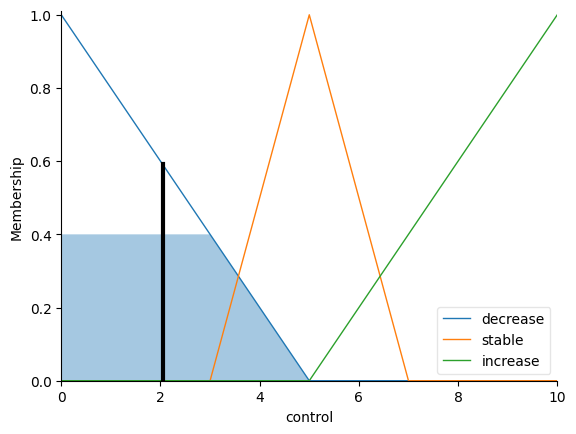

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

temp = ctrl.Antecedent(np.arange(0, 11, 1), 'temp')
pressure = ctrl.Antecedent(np.arange(0, 11, 1), 'pressure')

control = ctrl.Consequent(np.arange(0, 11, 1), 'control')

temp['low'] = fuzz.trimf(temp.universe, [0, 0, 5])
temp['medium'] = fuzz.trimf(temp.universe, [3, 5, 7])
temp['high'] = fuzz.trimf(temp.universe, [5, 10, 10])

pressure['low'] = fuzz.trimf(pressure.universe, [0, 0, 5])
pressure['medium'] = fuzz.trimf(pressure.universe, [3, 5, 7])
pressure['high'] = fuzz.trimf(pressure.universe, [5, 10, 10])

control['decrease'] = fuzz.trimf(control.universe, [0, 0, 5])
control['stable'] = fuzz.trimf(control.universe, [3, 5, 7])
control['increase'] = fuzz.trimf(control.universe, [5, 10, 10])

rule1 = ctrl.Rule(temp['high'] & pressure['high'], control['decrease'])
rule2 = ctrl.Rule(temp['medium'] & pressure['medium'], control['stable'])
rule3 = ctrl.Rule(temp['low'], control['increase'])

system = ctrl.ControlSystem([rule1, rule2, rule3])
sim = ctrl.ControlSystemSimulation(system)

sim.input['temp'] = 8
sim.input['pressure'] = 7

sim.compute()

print(sim.output['control'])

control.view(sim=sim)

2.259259259259259


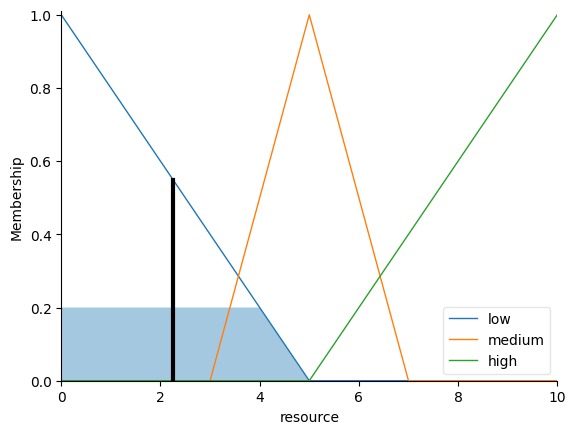

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

priority = ctrl.Antecedent(np.arange(0, 11, 1), 'priority')
complexity = ctrl.Antecedent(np.arange(0, 11, 1), 'complexity')
roi = ctrl.Antecedent(np.arange(0, 11, 1), 'roi')

resource = ctrl.Consequent(np.arange(0, 11, 1), 'resource')

priority['low'] = fuzz.trimf(priority.universe, [0, 0, 5])
priority['medium'] = fuzz.trimf(priority.universe, [3, 5, 7])
priority['high'] = fuzz.trimf(priority.universe, [5, 10, 10])

complexity['low'] = fuzz.trimf(complexity.universe, [0, 0, 5])
complexity['medium'] = fuzz.trimf(complexity.universe, [3, 5, 7])
complexity['high'] = fuzz.trimf(complexity.universe, [5, 10, 10])

roi['low'] = fuzz.trimf(roi.universe, [0, 0, 5])
roi['medium'] = fuzz.trimf(roi.universe, [3, 5, 7])
roi['high'] = fuzz.trimf(roi.universe, [5, 10, 10])

resource['low'] = fuzz.trimf(resource.universe, [0, 0, 5])
resource['medium'] = fuzz.trimf(resource.universe, [3, 5, 7])
resource['high'] = fuzz.trimf(resource.universe, [5, 10, 10])

rule1 = ctrl.Rule(priority['high'] & roi['high'] & complexity['low'], resource['high'])
rule2 = ctrl.Rule(priority['medium'] & roi['medium'], resource['medium'])
rule3 = ctrl.Rule(priority['low'] | roi['low'] | complexity['high'], resource['low'])

system = ctrl.ControlSystem([rule1, rule2, rule3])
sim = ctrl.ControlSystemSimulation(system)

sim.input['priority'] = 8
sim.input['complexity'] = 6
sim.input['roi'] = 7

sim.compute()

print(sim.output['resource'])

resource.view(sim=sim)

5.0


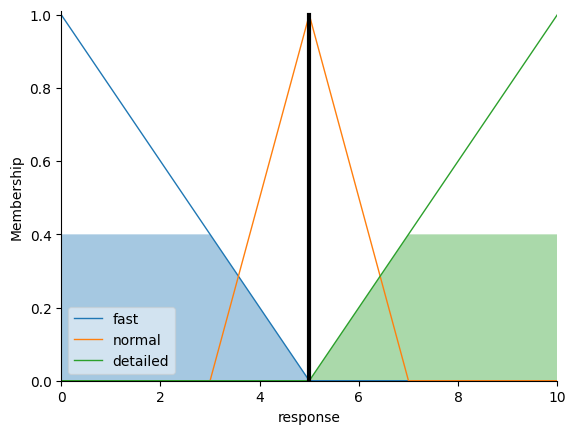

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

complexity = ctrl.Antecedent(np.arange(0, 11, 1), 'complexity')
mood = ctrl.Antecedent(np.arange(0, 11, 1), 'mood')

response = ctrl.Consequent(np.arange(0, 11, 1), 'response')

complexity['easy'] = fuzz.trimf(complexity.universe, [0, 0, 5])
complexity['medium'] = fuzz.trimf(complexity.universe, [3, 5, 7])
complexity['hard'] = fuzz.trimf(complexity.universe, [5, 10, 10])

mood['angry'] = fuzz.trimf(mood.universe, [0, 0, 5])
mood['normal'] = fuzz.trimf(mood.universe, [3, 5, 7])
mood['happy'] = fuzz.trimf(mood.universe, [5, 10, 10])

response['fast'] = fuzz.trimf(response.universe, [0, 0, 5])
response['normal'] = fuzz.trimf(response.universe, [3, 5, 7])
response['detailed'] = fuzz.trimf(response.universe, [5, 10, 10])

rule1 = ctrl.Rule(mood['angry'], response['fast'])
rule2 = ctrl.Rule(complexity['hard'], response['detailed'])
rule3 = ctrl.Rule(complexity['medium'] & mood['normal'], response['normal'])

system = ctrl.ControlSystem([rule1, rule2, rule3])
sim = ctrl.ControlSystemSimulation(system)

sim.input['complexity'] = 7
sim.input['mood'] = 3

sim.compute()

print(sim.output['response'])

response.view(sim=sim)

Gia cuoc tinh toan: 93.96


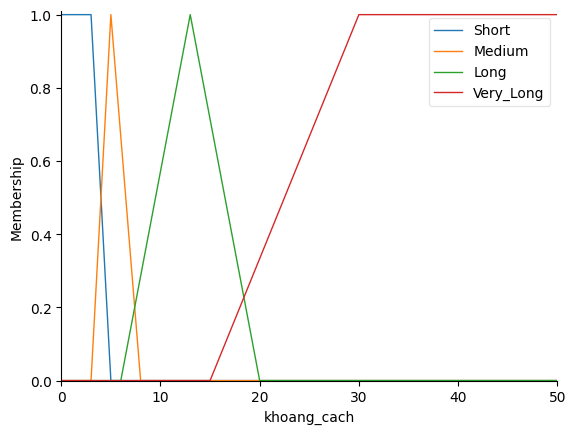

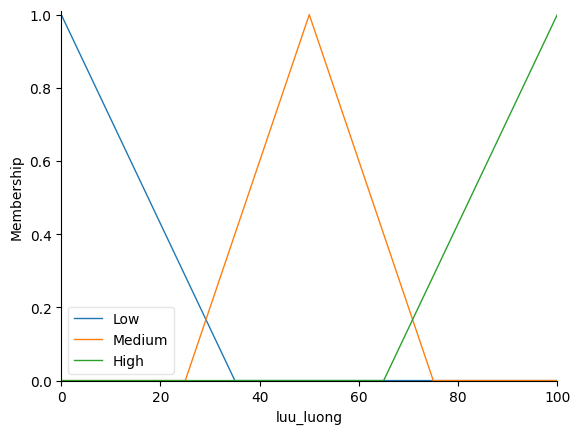

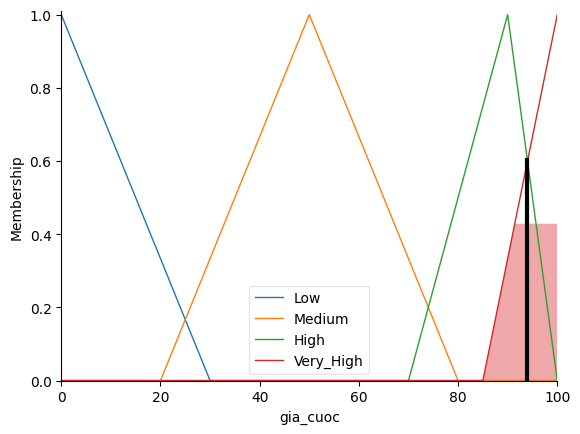

In [17]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

khoang_cach = ctrl.Antecedent(np.arange(0, 51, 1), 'khoang_cach')
luu_luong = ctrl.Antecedent(np.arange(0, 101, 1), 'luu_luong')
nhu_cau = ctrl.Antecedent(np.arange(0, 101, 1), 'nhu_cau')
thoi_tiet = ctrl.Antecedent(np.arange(0, 11, 1), 'thoi_tiet')
gia_cuoc = ctrl.Consequent(np.arange(0, 101, 1), 'gia_cuoc')

khoang_cach['Short'] = fuzz.trapmf(khoang_cach.universe, [0, 0, 3, 5])
khoang_cach['Medium'] = fuzz.trimf(khoang_cach.universe, [3, 5, 8])
khoang_cach['Long'] = fuzz.trimf(khoang_cach.universe, [6, 13, 20])
khoang_cach['Very_Long'] = fuzz.trapmf(khoang_cach.universe, [15, 30, 50, 50])

luu_luong['Low'] = fuzz.trimf(luu_luong.universe, [0, 0, 35])
luu_luong['Medium'] = fuzz.trimf(luu_luong.universe, [25, 50, 75])
luu_luong['High'] = fuzz.trimf(luu_luong.universe, [65, 100, 100])

nhu_cau['Low'] = fuzz.trimf(nhu_cau.universe, [0, 0, 35])
nhu_cau['Medium'] = fuzz.trimf(nhu_cau.universe, [25, 50, 75])
nhu_cau['High'] = fuzz.trimf(nhu_cau.universe, [65, 100, 100])

thoi_tiet['Good'] = fuzz.trimf(thoi_tiet.universe, [0, 0, 4])
thoi_tiet['Moderate'] = fuzz.trimf(thoi_tiet.universe, [3, 5, 7])
thoi_tiet['Bad'] = fuzz.trimf(thoi_tiet.universe, [6, 10, 10])

gia_cuoc['Low'] = fuzz.trimf(gia_cuoc.universe, [0, 0, 30])
gia_cuoc['Medium'] = fuzz.trimf(gia_cuoc.universe, [20, 50, 80])
gia_cuoc['High'] = fuzz.trimf(gia_cuoc.universe, [70, 90, 100])
gia_cuoc['Very_High'] = fuzz.trimf(gia_cuoc.universe, [85, 100, 100])

rule1 = ctrl.Rule(khoang_cach['Short'] & luu_luong['Low'] & nhu_cau['Low'], gia_cuoc['Low'])
rule2 = ctrl.Rule(khoang_cach['Short'] & luu_luong['Medium'] & nhu_cau['High'], gia_cuoc['Medium'])
rule3 = ctrl.Rule(khoang_cach['Medium'] & luu_luong['High'] & nhu_cau['High'], gia_cuoc['High'])
rule4 = ctrl.Rule(khoang_cach['Long'] & luu_luong['Medium'] & thoi_tiet['Good'], gia_cuoc['Medium'])
rule5 = ctrl.Rule(khoang_cach['Long'] & luu_luong['High'] & thoi_tiet['Bad'], gia_cuoc['Very_High'])

grab_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)

grab_sim.input['khoang_cach'] = 15
grab_sim.input['luu_luong'] = 80
grab_sim.input['nhu_cau'] = 70
grab_sim.input['thoi_tiet'] = 9

grab_sim.compute()

print(f"Gia cuoc tinh toan: {grab_sim.output['gia_cuoc']:.2f}")

khoang_cach.view()
luu_luong.view()
gia_cuoc.view(sim=grab_sim)

plt.show()

54.99999999999998


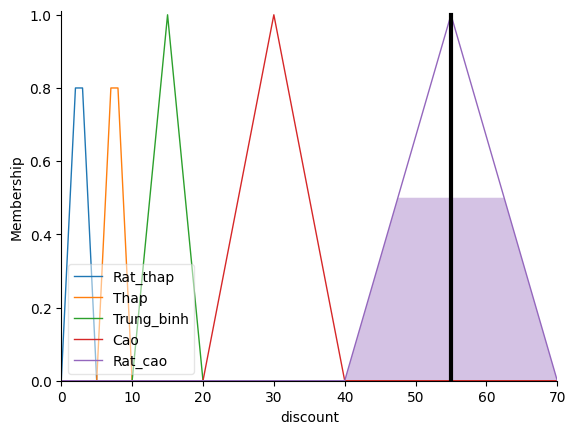

In [21]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal_event')
competitor_discount = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_discount')
discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

rating['Thap'] = fuzz.trapmf(rating.universe, [0, 0, 3.5, 4.0])
rating['Trung_binh'] = fuzz.trimf(rating.universe, [4.0, 4.25, 4.5])
rating['Cao'] = fuzz.trapmf(rating.universe, [4.5, 4.75, 5.0, 5.0])

sales_volume['Thap'] = fuzz.trimf(sales_volume.universe, [0, 0, 40])
sales_volume['Trung_binh'] = fuzz.trimf(sales_volume.universe, [30, 50, 70])
sales_volume['Cao'] = fuzz.trimf(sales_volume.universe, [60, 100, 100])

profit_margin['Thap'] = fuzz.trimf(profit_margin.universe, [0, 0, 40])
profit_margin['Trung_binh'] = fuzz.trimf(profit_margin.universe, [30, 50, 70])
profit_margin['Cao'] = fuzz.trimf(profit_margin.universe, [60, 100, 100])

seasonal_event['Khong'] = fuzz.trimf(seasonal_event.universe, [0, 0, 3])
seasonal_event['Trung_binh'] = fuzz.trimf(seasonal_event.universe, [2, 5, 8])
seasonal_event['Cao'] = fuzz.trimf(seasonal_event.universe, [7, 10, 10])

competitor_discount['Thap'] = fuzz.trimf(competitor_discount.universe, [0, 0, 40])
competitor_discount['Trung_binh'] = fuzz.trimf(competitor_discount.universe, [30, 50, 70])
competitor_discount['Cao'] = fuzz.trimf(competitor_discount.universe, [60, 100, 100])

discount['Rat_thap'] = fuzz.trimf(discount.universe, [0, 2.5, 5])
discount['Thap'] = fuzz.trimf(discount.universe, [5, 7.5, 10])
discount['Trung_binh'] = fuzz.trimf(discount.universe, [10, 15, 20])
discount['Cao'] = fuzz.trimf(discount.universe, [20, 30, 40])
discount['Rat_cao'] = fuzz.trimf(discount.universe, [40, 55, 70])

rules = [
    ctrl.Rule(rating['Cao'] & sales_volume['Cao'] & profit_margin['Cao'], discount['Rat_thap']),
    ctrl.Rule(rating['Thap'] & sales_volume['Thap'] & profit_margin['Cao'], discount['Cao']),
    ctrl.Rule(seasonal_event['Cao'] & competitor_discount['Cao'], discount['Rat_cao']),
    ctrl.Rule(rating['Trung_binh'] & sales_volume['Trung_binh'] & profit_margin['Trung_binh'], discount['Trung_binh']),
    ctrl.Rule(competitor_discount['Thap'] & profit_margin['Thap'] & sales_volume['Cao'], discount['Rat_thap']),
    ctrl.Rule(rating['Thap'] & seasonal_event['Khong'], discount['Trung_binh']),
    ctrl.Rule(sales_volume['Thap'] & profit_margin['Thap'], discount['Rat_thap'])
]

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['rating'] = 4.3
discount_sim.input['sales_volume'] = 50
discount_sim.input['profit_margin'] = 20
discount_sim.input['seasonal_event'] = 9
discount_sim.input['competitor_discount'] = 80

discount_sim.compute()
print(discount_sim.output['discount'])

discount.view(sim=discount_sim)
plt.show()

Mức giảm giá đề xuất:  20.0 %


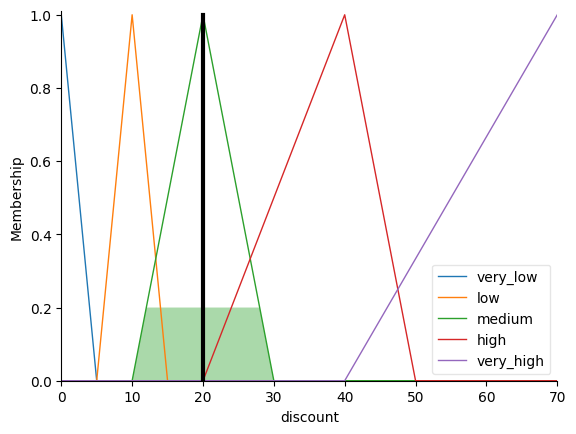

In [12]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

demand = ctrl.Antecedent(np.arange(0, 11, 1), 'demand')
competition = ctrl.Antecedent(np.arange(0, 11, 1), 'competition')
reputation = ctrl.Antecedent(np.arange(0, 11, 1), 'reputation')
profit = ctrl.Antecedent(np.arange(0, 11, 1), 'profit')
season = ctrl.Antecedent(np.arange(0, 11, 1), 'season')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

for var in [demand, competition, reputation, profit, season]:
    var['low'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['medium'] = fuzz.trimf(var.universe, [0, 5, 10])
    var['high'] = fuzz.trimf(var.universe, [5, 10, 10])

discount['very_low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [5, 10, 15])
discount['medium'] = fuzz.trimf(discount.universe, [10, 20, 30])
discount['high'] = fuzz.trimf(discount.universe, [20, 40, 50])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 70, 70])


rule1 = ctrl.Rule(demand['high'] & competition['low'] & profit['low'], discount['very_low'])

rule2 = ctrl.Rule(demand['low'] & competition['high'] & profit['high'], discount['high'])

rule3 = ctrl.Rule(reputation['high'] & profit['medium'] & season['high'], discount['medium'])

rule4 = ctrl.Rule(competition['high'] & season['high'] & profit['high'], discount['very_high'])

rule5 = ctrl.Rule(reputation['low'] & demand['medium'] & profit['low'], discount['medium'])

rule6 = ctrl.Rule(demand['high'] & season['low'] & competition['low'], discount['very_low'])

rule7 = ctrl.Rule(profit['high'] & competition['medium'] & season['medium'], discount['medium'])

discount_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7
])

discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['demand'] = 9
discount_sim.input['competition'] = 5
discount_sim.input['reputation'] = 5
discount_sim.input['profit'] = 9
discount_sim.input['season'] = 9

discount_sim.compute()

print("Mức giảm giá đề xuất: ", round(discount_sim.output['discount'], 2), "%")

discount.view(sim=discount_sim)

Số lượng đơn hàng cần kết hợp: 8.22
Mức độ ưu tiên giao hàng: 50.00%


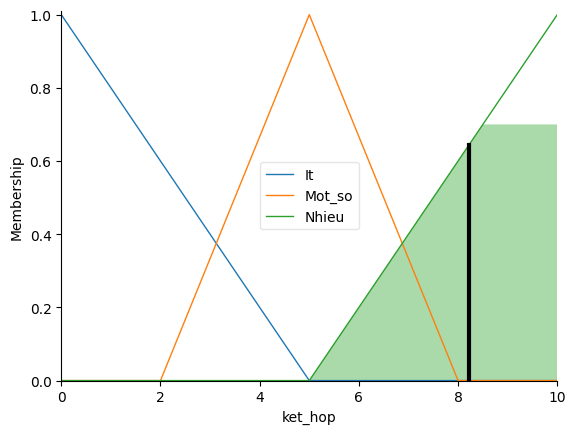

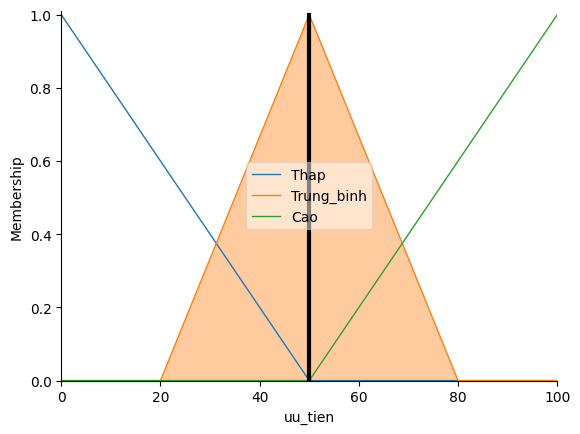

In [25]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

mat_do = ctrl.Antecedent(np.arange(0, 101, 1), 'mat_do')
khan_cap = ctrl.Antecedent(np.arange(0, 101, 1), 'khan_cap')
tai_trong = ctrl.Antecedent(np.arange(0, 101, 1), 'tai_trong')
giao_thong = ctrl.Antecedent(np.arange(0, 101, 1), 'giao_thong')
loi_nhuan = ctrl.Antecedent(np.arange(0, 101, 1), 'loi_nhuan')

ket_hop = ctrl.Consequent(np.arange(0, 11, 1), 'ket_hop')
uu_tien = ctrl.Consequent(np.arange(0, 101, 1), 'uu_tien')

for var in [mat_do, khan_cap, tai_trong, giao_thong, loi_nhuan]:
    var['Thap'] = fuzz.trimf(var.universe, [0, 0, 50])
    var['Trung_binh'] = fuzz.trimf(var.universe, [20, 50, 80])
    var['Cao'] = fuzz.trimf(var.universe, [50, 100, 100])

ket_hop['It'] = fuzz.trimf(ket_hop.universe, [0, 0, 5])
ket_hop['Mot_so'] = fuzz.trimf(ket_hop.universe, [2, 5, 8])
ket_hop['Nhieu'] = fuzz.trimf(ket_hop.universe, [5, 10, 10])

uu_tien['Thap'] = fuzz.trimf(uu_tien.universe, [0, 0, 50])
uu_tien['Trung_binh'] = fuzz.trimf(uu_tien.universe, [20, 50, 80])
uu_tien['Cao'] = fuzz.trimf(uu_tien.universe, [50, 100, 100])

rules = [
    ctrl.Rule(mat_do['Cao'] & tai_trong['Thap'], ket_hop['Nhieu']),
    ctrl.Rule(mat_do['Trung_binh'] & giao_thong['Trung_binh'], ket_hop['Mot_so']),
    ctrl.Rule(mat_do['Thap'] | tai_trong['Cao'], ket_hop['It']),

    ctrl.Rule(khan_cap['Cao'] & loi_nhuan['Cao'], uu_tien['Cao']),
    ctrl.Rule(khan_cap['Trung_binh'] | giao_thong['Trung_binh'], uu_tien['Trung_binh']),
    ctrl.Rule(khan_cap['Thap'], uu_tien['Thap'])
]


logistics_ctrl = ctrl.ControlSystem(rules)
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)


logistics_sim.input['mat_do'] = 85
logistics_sim.input['khan_cap'] = 50
logistics_sim.input['tai_trong'] = 15
logistics_sim.input['giao_thong'] = 50
logistics_sim.input['loi_nhuan'] = 50


try:
    logistics_sim.compute()

    print(f"Số lượng đơn hàng cần kết hợp: {logistics_sim.output['ket_hop']:.2f}")
    print(f"Mức độ ưu tiên giao hàng: {logistics_sim.output['uu_tien']:.2f}%")

    ket_hop.view(sim=logistics_sim)
    uu_tien.view(sim=logistics_sim)
    plt.show()

except KeyError as e:
    print(f"Lỗi: Không thể tính toán đầu ra {e}. Hãy kiểm tra lại các luật mờ (Rules).")